This notebook serves a comparison purpose between few controll variables for future steps. The required setup is:

1. `density=0.25`
2. `shots=1000`
3. `seed=123` (following the previous IBM Fez experiment.)
4. `lengths = [2]+[4,10,20,50]`
5. Compare between `'edge_grab'`, `'matching'` and `'new'`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit.transpiler import Target, CouplingMap
from qiskit.quantum_info import Operator
from qiskit.circuit.library import CXGate  # <-- Add this import
from qiskit_device_benchmarking.bench_code.mrb import MirrorQA, QuantumAwesomeness
import os, random

# Fix random seed for numpy
SEED = 123 # pick your favorite int
os.environ["PYTHONHASHSEED"] = str(SEED)  # optional, for hash-based determinism
random.seed(SEED)
np.random.seed(SEED)

In [2]:
# Define parameters for the simulated backend
num_qubits = 16
basis_gates = ["id", "h", "x", "y", "z", "rz", "cx"]
p2 = 1e-2 # 2-qubit gate error probability
p1 = p2/10  # 1-qubit gate error probability
rz_angle = np.pi / 2  # Match initial_entangling_angle

shots = 1000 # 10000
lengths = [2]+[4,10,20,50] # ,100
num_samples = 20
 
cmap = CouplingMap.from_grid(4, 4, bidirectional=True)

In [3]:
# Create a Target object to define the gates, including rz explicitly
target = Target.from_configuration(
    num_qubits=num_qubits,
    basis_gates=basis_gates,
    coupling_map=cmap,
    custom_name_mapping={
        "id": Operator(np.array([[1, 0], [0, 1]])),  # Identity gate
        "h": Operator(np.array([[1, 1], [1, -1]]) / np.sqrt(2)),  # Hadamard gate
        "x": Operator(np.array([[0, 1], [1, 0]])),  # Pauli X gate
        "y": Operator(np.array([[0, -1j], [1j, 0]])),  # Pauli Y gate
        "z": Operator(np.array([[1, 0], [0, -1]])),  # Pauli Z gate
        "rz": Operator(
            [
                [np.cos(rz_angle / 2), -1j * np.sin(rz_angle / 2)],
                [-1j * np.sin(rz_angle / 2), np.cos(rz_angle / 2)],
            ]
        ),  # RZ(π/2)
        "cx": Operator(
            np.array([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0]])
        ),  # CNOT gate
    },
)

# Create a noise model to emulate the NoisyBackend
noise_model = NoiseModel()

# Add depolarizing errors for 1-qubit and 2-qubit gates
error_1q = depolarizing_error(p1, 1)
error_2q = depolarizing_error(p2, 2)

# Apply errors to all basis gates except 'delay' and 'reset'
for gate in basis_gates:
    if gate in ["id", "h", "x", "y", "z", "rz"]:
        noise_model.add_all_qubit_quantum_error(error_1q, gate)
    elif gate == "cx":
        noise_model.add_all_qubit_quantum_error(error_2q, gate)

In [4]:
# Set up the AerSimulator with stabilizer method, target, and noise model
backend = AerSimulator(
    method="stabilizer",
    noise_model=noise_model if (p1 > 0 or p2 > 0) else None,
    target=target,
    max_parallel_threads=0,
    max_parallel_experiments=0,
    seed_simulator=SEED
)

In [38]:
# Test out the odd-even pattern sampler (different method of building, compared to NewSampler!)
exp = MirrorQA(
    range(num_qubits),
    lengths=lengths,
    backend=backend,
    two_qubit_gate_density=0.25,
    num_samples=num_samples,
    initial_entangling_angle=np.pi / 2,
    sampling_algorithm="chess",  # 'edge_grab', 'matching', 'new', 'chess'
    seed=SEED,
    # full_sampling=True
)

# Set run options
exp.set_run_options(shots=shots)

rb_data = exp.run()
print(rb_data.job_ids)

# Print all available rounds, not a fixed range
for i in range(len(exp._pairs)):
    print(f"Pairs in outermost layer for circuit with {lengths[i%len(lengths)]} rounds", exp._pairs[i])

['c0266d41-3bb1-4685-8286-51b5aa1bb00e']
Pairs in outermost layer for circuit with 2 rounds []
Pairs in outermost layer for circuit with 4 rounds [(4, 0), (10, 11), (5, 1), (13, 9), (7, 6), (8, 12), (3, 2), (14, 15)]
Pairs in outermost layer for circuit with 10 rounds []
Pairs in outermost layer for circuit with 20 rounds [(0, 1), (9, 13), (11, 10), (5, 4), (2, 3), (6, 7), (8, 12), (14, 15)]
Pairs in outermost layer for circuit with 50 rounds []
Pairs in outermost layer for circuit with 2 rounds []
Pairs in outermost layer for circuit with 4 rounds [(1, 2), (0, 4), (7, 3), (14, 13), (11, 15), (10, 6), (8, 12), (5, 9)]
Pairs in outermost layer for circuit with 10 rounds []
Pairs in outermost layer for circuit with 20 rounds [(0, 1), (6, 2), (11, 10), (7, 3), (13, 12), (4, 8), (5, 9), (14, 15)]
Pairs in outermost layer for circuit with 50 rounds []
Pairs in outermost layer for circuit with 2 rounds []
Pairs in outermost layer for circuit with 4 rounds [(10, 11), (0, 4), (1, 5), (2, 3), (

In [27]:
print("Pairs:", exp._pairs[0])
# print(f'{exp._static_trans_circuits[0].depth()} VS {exp._static_trans_circuits[4].depth()}')
exp._static_trans_circuits[0].draw(fold=-1)

Pairs: []


global phase: π
         ┌───┐ ░    ┌───┐   ┌─────────┐                 ░ ┌───┐ ░    ┌───┐   ┌─────────┐   ┌───┐   ┌─────────┐      ░       ░  ░ ┌─┐                                             
    q_0: ┤ Y ├─░────┤ H ├───┤ Rz(π/2) ├─────────────────░─┤ Z ├─░────┤ H ├───┤ Rz(π/2) ├───┤ H ├───┤ Rz(π/2) ├──────░───────░──░─┤M├─────────────────────────────────────────────
         └───┘ ░ ┌──┴───┴──┐└──┬───┬──┘┌─────────┐┌───┐ ░ └───┘ ░ ┌──┴───┴──┐└──┬───┬──┘┌──┴───┴──┐└──┬───┬──┘      ░ ┌───┐ ░  ░ └╥┘┌─┐                                          
    q_1: ──────░─┤ Rz(π/2) ├───┤ H ├───┤ Rz(π/2) ├┤ Z ├─░───────░─┤ Rz(π/2) ├───┤ H ├───┤ Rz(π/2) ├───┤ Z ├─────────░─┤ Z ├─░──░──╫─┤M├──────────────────────────────────────────
               ░ └──┬───┬──┘┌──┴───┴──┐└──┬───┬──┘└───┘ ░ ┌───┐ ░ └──┬───┬──┘┌──┴───┴──┐└──┬───┬──┘┌──┴───┴──┐┌───┐ ░ ├───┤ ░  ░  ║ └╥┘┌─┐                                       
    q_2: ──────░────┤ H ├───┤ Rz(π/2) ├───┤ Y ├─────────░─┤ Y ├─░────┤ H ├───┤ Rz(π/2) ├───┤ H ├───┤ Rz(π/2) ├┤ Z ├─░─┤ Z ├─░──░──╫──╫─┤M├───────────────────────────────────────
               ░    ├───┤   └─────────┘   └───┘         ░ ├───┤ ░    ├───┤   └─────────┘   └───┘   └─────────┘└───┘ ░ ├───┤ ░  ░  ║  ║ └╥┘┌─┐                                    
    q_3: ──────░────┤ X ├───────────────────────────────░─┤ X ├─░────┤ X ├──────────────────────────────────────────░─┤ Z ├─░──░──╫──╫──╫─┤M├────────────────────────────────────
               ░    ├───┤      ┌───┐                    ░ ├───┤ ░    ├───┤      ┌───┐                               ░ ├───┤ ░  ░  ║  ║  ║ └╥┘┌─┐                                 
    q_4: ──────░────┤ H ├──────┤ Z ├────────────────────░─┤ X ├─░────┤ H ├──────┤ X ├───────────────────────────────░─┤ Z ├─░──░──╫──╫──╫──╫─┤M├─────────────────────────────────
         ┌───┐ ░ ┌──┴───┴──┐   ├───┤   ┌─────────┐┌───┐ ░ ├───┤ ░ ┌──┴───┴──┐   ├───┤   ┌─────────┐   ┌───┐         ░ ├───┤ ░  ░  ║  ║  ║  ║ └╥┘┌─┐                              
    q_5: ┤ Z ├─░─┤ Rz(π/2) ├───┤ H ├───┤ Rz(π/2) ├┤ Z ├─░─┤ X ├─░─┤ Rz(π/2) ├───┤ H ├───┤ Rz(π/2) ├───┤ Z ├─────────░─┤ Z ├─░──░──╫──╫──╫──╫──╫─┤M├──────────────────────────────
         ├───┤ ░ └──┬───┬──┘   ├───┤   └─────────┘└───┘ ░ ├───┤ ░ └──┬───┬──┘   ├───┤   └─────────┘   └───┘         ░ ├───┤ ░  ░  ║  ║  ║  ║  ║ └╥┘┌─┐                           
    q_6: ┤ Z ├─░────┤ H ├──────┤ X ├────────────────────░─┤ Y ├─░────┤ H ├──────┤ Z ├───────────────────────────────░─┤ Y ├─░──░──╫──╫──╫──╫──╫──╫─┤M├───────────────────────────
         ├───┤ ░    ├───┤      └───┘                    ░ ├───┤ ░    ├───┤      └───┘                               ░ ├───┤ ░  ░  ║  ║  ║  ║  ║  ║ └╥┘┌─┐                        
    q_7: ┤ X ├─░────┤ Y ├───────────────────────────────░─┤ Y ├─░────┤ Y ├──────────────────────────────────────────░─┤ Y ├─░──░──╫──╫──╫──╫──╫──╫──╫─┤M├────────────────────────
         ├───┤ ░    ├───┤                               ░ ├───┤ ░    ├───┤                                          ░ ├───┤ ░  ░  ║  ║  ║  ║  ║  ║  ║ └╥┘┌─┐                     
    q_8: ┤ Z ├─░────┤ H ├───────────────────────────────░─┤ X ├─░────┤ H ├──────────────────────────────────────────░─┤ Z ├─░──░──╫──╫──╫──╫──╫──╫──╫──╫─┤M├─────────────────────
         ├───┤ ░    ├───┤      ┌───┐                    ░ └───┘ ░    ├───┤      ┌───┐                               ░ ├───┤ ░  ░  ║  ║  ║  ║  ║  ║  ║  ║ └╥┘┌─┐                  
    q_9: ┤ Z ├─░────┤ H ├──────┤ Y ├────────────────────░───────░────┤ H ├──────┤ Y ├───────────────────────────────░─┤ Y ├─░──░──╫──╫──╫──╫──╫──╫──╫──╫──╫─┤M├──────────────────
         ├───┤ ░    ├───┤   ┌──┴───┴──┐                 ░       ░    ├───┤   ┌──┴───┴──┐   ┌───┐   ┌─────────┐      ░ ├───┤ ░  ░  ║  ║  ║  ║  ║  ║  ║  ║  ║ └╥┘┌─┐               
   q_10: ┤ Y ├─░────┤ H ├───┤ Rz(π/2) ├─────────────────░───────░────┤ H ├───┤ Rz(π/2) ├───┤ H ├───┤ Rz(π/2) ├──────░─┤ Z ├─░──░──╫──╫──╫──╫──╫──╫──╫──╫──╫──╫─┤M├───────────────
         └───┘ ░    ├───┤   └─────────┘                 ░ ┌───┐ ░   

In [31]:
exp.analysis.set_options(analyzed_quantity="Effective Polarization")
analysis = exp.analysis.run(rb_data)

In [32]:
print(rb_data)

---------------------------------------------------
Experiment: MirrorQA
Experiment ID: 07f1675e-3834-44c4-9b31-4c0b2a23a207
Status: ExperimentStatus.DONE
Backend: AerSimulator('aer_simulator_stabilizer'
             noise_model=<NoiseModel on ['y', 'cx', 'x', 'z', 'id', 'h', 'rz']>)
Data: 100
Analysis Results: 3
Figures: 1
Artifacts: 2


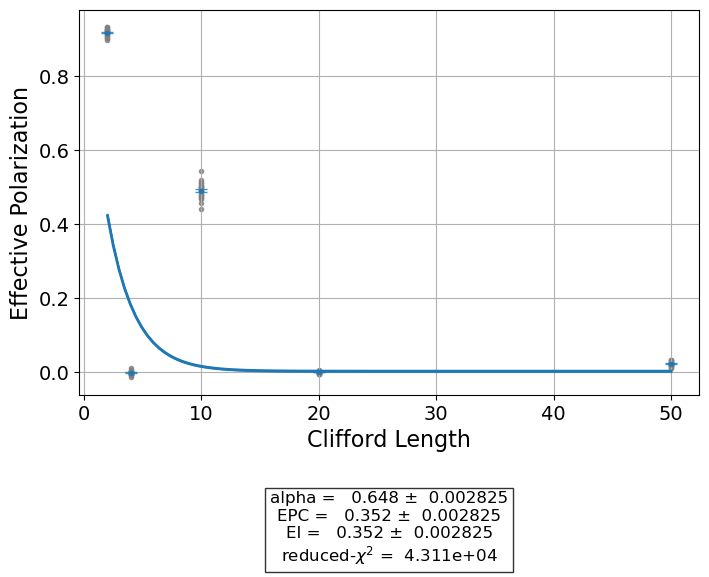

In [33]:
analysis.figure(0)

/Users/astrydpark/miniconda3/envs/awesomeness/lib/python3.13/site-packages/numpy/_core/_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/astrydpark/miniconda3/envs/awesomeness/lib/python3.13/site-packages/numpy/_core/_methods.py:180: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/Users/astrydpark/miniconda3/envs/awesomeness/lib/python3.13/site-packages/numpy/_core/_methods.py:214: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/astrydpark/miniconda3/envs/awesomeness/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/astrydpark/miniconda3/envs/awesomeness/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype

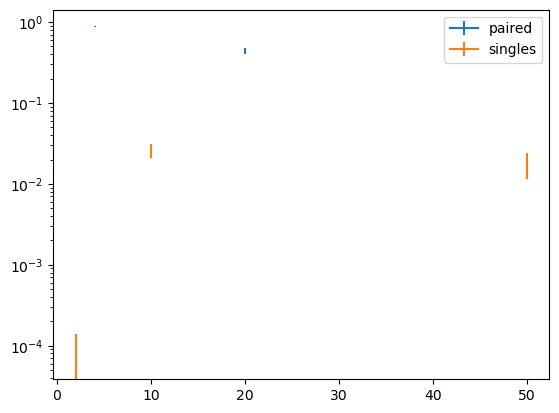

In [35]:
qa = QuantumAwesomeness(exp.backend.coupling_map)

mi = qa.mutual_info(rb_data.data())
mmi = qa.mean_mutual_info(rb_data.data(), exp._pairs)

num_lengths = len(lengths)
ys = [[[] for _ in range(num_lengths)] for _ in range(2)]
yerrs = [[], []]

for p, pairtype in enumerate(["paired", "singles"]):
    for j, m in enumerate(mmi[pairtype]):
        if m is not np.nan:
            ys[p][j % num_lengths].append(m)
    for j in range(num_lengths):
        yerrs[p].append(np.std(ys[p][j]))
        ys[p][j] = np.mean(ys[p][j])

plt.errorbar(lengths, ys[0], yerr=yerrs[0], label="paired")
plt.errorbar(lengths, ys[1], yerr=yerrs[1], label="singles")
plt.yscale("log")
plt.legend()


In [36]:
mmi

{'paired': [nan,
  np.float64(0.8813829663471726),
  nan,
  np.float64(0.5039719330685088),
  nan,
  nan,
  np.float64(0.8629936802494661),
  nan,
  np.float64(0.4445210033458619),
  nan,
  nan,
  np.float64(0.8773889698986805),
  nan,
  np.float64(0.41559152280053574),
  nan,
  nan,
  np.float64(0.8769684111134768),
  nan,
  np.float64(0.48644641811945005),
  nan,
  nan,
  np.float64(0.8683757884385956),
  nan,
  np.float64(0.37518266198112205),
  nan,
  nan,
  np.float64(0.866124977372768),
  nan,
  np.float64(0.38222349863624483),
  nan,
  nan,
  np.float64(0.8643737731132708),
  nan,
  np.float64(0.5029010007282095),
  nan,
  nan,
  np.float64(0.8767606878391276),
  nan,
  np.float64(0.4433665396782879),
  nan,
  nan,
  np.float64(0.8776112432307377),
  nan,
  np.float64(0.4088209150539385),
  nan,
  nan,
  np.float64(0.8763060167847776),
  nan,
  np.float64(0.40823587079248547),
  nan,
  nan,
  np.float64(0.8829237123687196),
  nan,
  np.float64(0.46156016426752855),
  nan,
  nan,

In [22]:
# Set up the experiment 01 ('edge_grab'+0.25) object
exp01 = MirrorQA(
    range(num_qubits),
    lengths=lengths,
    backend=backend,
    two_qubit_gate_density=0.0, # aim for 1.0 and 0.5 for mirror_qa_topo (0.25 from Fez)
    num_samples=num_samples,
    initial_entangling_angle=np.pi/2,
    sampling_algorithm='edge_grab', # 'edge_grab', 'matching', 'new'
    seed=SEED
)

# Set run options
exp01.set_run_options(shots=shots)

rb_data_01 = exp01.run()
print(rb_data_01.job_ids)

for i in range(len(exp01._pairs)):
    print(f"Pairs from round {i}", exp01._pairs[i])

['63bdc804-167b-4f54-9c42-e069ee65a841']
Pairs from round 0 []
Pairs from round 1 []
Pairs from round 2 []
Pairs from round 3 []
Pairs from round 4 []
Pairs from round 5 []
Pairs from round 6 []
Pairs from round 7 []
Pairs from round 8 []
Pairs from round 9 []
Pairs from round 10 []
Pairs from round 11 []
Pairs from round 12 []
Pairs from round 13 []
Pairs from round 14 []
Pairs from round 15 []
Pairs from round 16 []
Pairs from round 17 []
Pairs from round 18 []
Pairs from round 19 []
Pairs from round 20 []
Pairs from round 21 []
Pairs from round 22 []
Pairs from round 23 []
Pairs from round 24 []
Pairs from round 25 []
Pairs from round 26 []
Pairs from round 27 []
Pairs from round 28 []
Pairs from round 29 []
Pairs from round 30 []
Pairs from round 31 []
Pairs from round 32 []
Pairs from round 33 []
Pairs from round 34 []
Pairs from round 35 []
Pairs from round 36 []
Pairs from round 37 []
Pairs from round 38 []
Pairs from round 39 []
Pairs from round 40 []
Pairs from round 41 []
Pai

In [ ]:
# Set up the experiment 02 ('matching'+0.25) object
exp02 = MirrorQA(
    range(num_qubits),
    lengths=lengths,
    backend=backend,
    two_qubit_gate_density=0.0, # aim for 1.0 and 0.5 for mirror_qa_topo (0.25 from Fez)
    num_samples=num_samples,
    initial_entangling_angle=np.pi/2,
    sampling_algorithm='matching', # 'edge_grab', 'matching', 'new'
    seed=SEED
)

# Set run options
exp02.set_run_options(shots=shots)

rb_data_02 = exp02.run()
print(rb_data_02.job_ids)

for i in range(len(exp02._pairs)):
    print(f"Pairs from round {i}", exp02._pairs[i])

In [ ]:
# Set up the experiment 01 ('edge_grab'+0.25) object
exp03 = MirrorQA(
    range(num_qubits),
    lengths=lengths,
    backend=backend,
    two_qubit_gate_density=0.25, 
    num_samples=num_samples,
    initial_entangling_angle=np.pi/2,
    sampling_algorithm='new', # 'edge_grab', 'matching', 'new'
    seed=SEED,
    # full_sampling=True
)

# Set run options
exp03.set_run_options(shots=shots)

rb_data_03 = exp03.run()
print(rb_data_03.job_ids)

# Print all available rounds, not a fixed range
for i in range(len(exp03._pairs)):
    print(f"Pairs from round {i}", exp03._pairs[i])

In [ ]:
# *** It's stuck here ***
exp03.analysis.set_options(analyzed_quantity="Effective Polarization")
# exp.analysis.set_options(analyzed_quantity='Mutual Information')

In [ ]:
analysis = exp03.analysis.run(rb_data_03)

In [ ]:
# job id: '4d59ce51-72cc-4f0e-99ed-c2ee2e907ffa' (from Tue 9 Feb 09:20)
print(rb_data_03)

In [ ]:
analysis.figure(0)

In [ ]:
qa = QuantumAwesomeness(exp03.backend.coupling_map)

mi = qa.mutual_info(rb_data_03.data())
mmi = qa.mean_mutual_info(rb_data_03.data(), exp03._pairs)

num_lengths = len(lengths)
ys = [[[] for _ in range(num_lengths)] for _ in range(2)]
yerrs = [[], []]

for p, pairtype in enumerate(["paired", "singles"]):
    for j, m in enumerate(mmi[pairtype]):
        if m is not np.nan:
            ys[p][j % num_lengths].append(m)
    for j in range(num_lengths):
        yerrs[p].append(np.std(ys[p][j]))
        ys[p][j] = np.mean(ys[p][j])

plt.errorbar(lengths, ys[0], yerr=yerrs[0], label="paired")
plt.errorbar(lengths, ys[1], yerr=yerrs[1], label="singles")
plt.yscale("log")
plt.legend()